# Main for Energy Simulation 

Simulates the energy consumption for each track, calculates the SoC each truck would have and calculates the resulting load profiles for the freight forwarding locations 

This notebook is to be executed after data/data_handling/data-aquisition.ipynb and main_data_analysis.ipynb

### Imports 

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import seaborn as sns
import sys
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches 
import matplotlib.lines as mlines
import matplotlib.ticker as mticker

from utils.style_config import *

sys.path.append('energy_sim')
import data.data_handling.data_processing as dp
import energy_sim.sequential_analysis as sq

In [17]:
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 12,
    'text.latex.preamble': r'\usepackage{siunitx}'
})

## Perform Energy Simulation based on BET.OS script 

The energy simulation takes very long to run (in total approx. 24 h) and should just only be executed once 

First run the faulty_tracks() function to identify tracks with missing data (results will be saved in mismatched_tracks.csv)
Then run run_energy_sim() to calculate energy consumption for each track (results will be saved in tracks_filtered_with_energy.csv)
Run run_energy_sim() will additionally create zero_speed_tracks.csv which lists tracks that have no speed data

The outputs are saved as csvs

### Run once:

In [2]:
#faulty_tracks()

# trips_energy = run_energy_sim(override_mismatched_tracks=False)

# "Can either pass on trips_energy directly from the simulation or let the function read in tracks_with_energy_raw.csv"
# df_trip_energy = clean_energy_sim_data(trips=None)

### After running the energy simulation once, read the csv instead of excecuting the simulation

In [3]:
df_trip_energy= pd.read_csv('output/csvs/tracks_with_energy.csv', index_col='track_id')

In [4]:
df_trips = pd.read_csv('input/stations/tracks_filtered.csv', index_col='track_id')
df_trips['stop_time'] = pd.to_datetime(df_trips['stop_time'], format='ISO8601')
df_trips['start_time'] = pd.to_datetime(df_trips['start_time'], format='ISO8601')

df_stops = dp.process_stops_data(df_trips)
df_occ_energy = sq.combine_tracks_and_stops(df_stops = df_stops, df_tracks_with_energy = df_trip_energy)

### Calculate Battery charges and SoCs at the end of each activity *

In [62]:
# Constant charging powers 
charging_powers = {'home base': 350, 'industrial area': 350}
df_soc, public_charging = sq.truck_soc(df_activities = df_occ_energy, charging_powers = charging_powers, soc_min = 0.15)

________________________________________________________________________________
[Memory] Calling energy_sim.sequential_analysis.truck_soc...
truck_soc(df_activities=       vehicle_id  tour_id                        start_time  \
0               1        0  2021-09-10 11:04:53.598000+02:00   
1               1        0  2021-09-10 12:07:57.395000+02:00   
2               1        0  2021-09-10 12:57:54.718000+02:00   
3               1        0  2021-09-10 13:13:53.221000+02:00   
4               1        0  2021-09-10 13:25:20.146000+02:00   
...           ...      ...                               ...   
85247         163    18999  2024-01-04 15:16:00.434000+01:00   
85248         163    18999  2024-01-04 16:26:41.892000+01:00   
85249         163    18999  2024-01-05 12:02:24.568000+01:00   
85250         163    18999  2024-01-05 12:37:38.462000+01:00..., charging_powers={'home base': 350, 'industrial area': 350}, soc_min=0.15)
Freight Forwarder 1:
  Instances with soc < soc_min: 12

### Tour statistics *

In [63]:
"""
In contrast to df_tours, df_tours_energy also includes non-driving activities between tracks. 
Thus, some additional parameters are included

    Stop time is the stop time of the last track equivalently to df_tours, 
    End time additionally includes the time spent at the home base after the tour's last track (i.e. = start time of the next tour)
   
    driving_duration is the sum of the duration of all driving activities in the tour, equivalently to duration in df_tours
    duration is the time between the start of the tour's first track and the end of its last activity 
     (i.e the duration between the start of the tour and the start of the next tour)
"""

df_tours_energy = dp.aggregate_tours(df_soc, charging_powers, save=True, energy=True, min_soc=0.15)

Freight Forwarder 1:
  Instances with soc < soc_min: 215
  Percentage: 11.68% 

Freight Forwarder 2:
  Instances with soc < soc_min: 3
  Percentage: 0.33% 

Freight Forwarder 3:
  Instances with soc < soc_min: 35
  Percentage: 2.12% 

Freight Forwarder 4:
  Instances with soc < soc_min: 366
  Percentage: 34.76% 

Freight Forwarder 5:
  Instances with soc < soc_min: 12
  Percentage: 0.40% 

Freight Forwarder 6:
  Instances with soc < soc_min: 201
  Percentage: 3.89% 




Freight Forwarder 1 - SoC Statistics:
soc_min: Mean=65.50%, Median=77.34%, Min=-529.40%, Max=90.00%
  soc_min outliers below -50%: 245 (minimum: -529.40%)
soc_at_departure: Mean=85.91%, Median=90.00%, Min=-438.33%, Max=90.00%
  soc_at_departure outliers below -50%: 46 (minimum: -438.33%)
soc_at_arrival: Mean=70.89%, Median=81.97%, Min=-529.40%, Max=90.00%
  soc_at_arrival outliers below -50%: 137 (minimum: -529.40%)


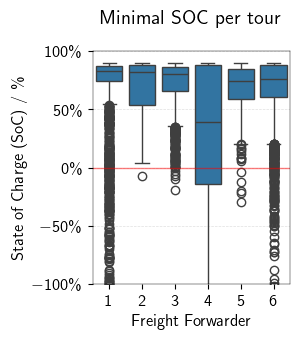

In [64]:

# Define cutoff for visualization
cutoff = -0.5  # -50% SoC 
    
# TODO adjust the plots into something meaninfull. Ideas:
# First See what the data looks like for different charging strategies. Then:
# 1) plot the amount (ratio of occurences to total tours) of SoCs below a certain threshold = 0.15
# 2) plot the distance travelled under the SoC threshold = 0.15
# 3) maybe try a cumulative density plot with SoC on x axis and the number of occurences on the y axis 
#    (SoC = 1 is the origen), up to threshold the plot is green, afterwards orange
# 4) try a histplot?? https://seaborn.pydata.org/examples/histogram_stacked.html 
#    (what could be important additional information? one plot with all ffs, or maybe length of tour?)

# TODO See alternative plot verion in notes for plot in the same format of weekly distance boxplot  
df_soc_plot = df_tours_energy.copy()
#result = dv.plot_soc_by_freight_forwarder_symlog(df_soc_plot)


# -------------------------------------------------------------------------------------------
#                           SOC BY FREIGHT FORWARDER BOXPLOTS (ENERGY)
# -------------------------------------------------------------------------------------------

def plot_soc_by_freight_forwarder(df_tours_energy, charging_powers, ff):
    """
    Create boxplots showing the distribution of minimum, SoC at departure, and SoC at arrival values
    for each freight forwarder, with each freight forwarder in a separate plot.
    Plot is cut off at -20% SoC but boxplot statistics include all data.
    
    Parameters:
    -----------
    df_tours_energy : pandas.DataFrame
        DataFrame containing tour energy data with soc_min, soc_at_departure, soc_at_arrival, and freight_forwarder columns
    """
        
    # Create single figure with 3x2 grid layout like plot_weekly_energy_demand_boxplot2
    fig, ax = plt.subplots(figsize=(textwidth / 2, h_169))
    
    # Calculate and print SoC statistics for the current freight forwarder
    print(f"\nFreight Forwarder {ff} - SoC Statistics:")
    for soc_type in ['soc_min', 'soc_at_departure', 'soc_at_arrival']:
        data = df_tours_energy[soc_type]
        print(f"{soc_type}: Mean={data.mean():.2%}, Median={data.median():.2%}, Min={data.min():.2%}, Max={data.max():.2%}")
        # Count outliers below cutoff
        outliers = data[data < cutoff]
        if len(outliers) > 0:
            print(f"  {soc_type} outliers below {cutoff:.0%}: {len(outliers)} (minimum: {outliers.min():.2%})")
    
    # Prepare boxplot data
    min_soc_data = df_tours_energy['soc_min']
    departure_soc_data = df_tours_energy['soc_at_departure'] 
    arrival_soc_data = df_tours_energy['soc_at_arrival']
    
    # Create boxplots for min, departure, and arrival SoC
    scaling_factor = textwidth / 16
    
    sns.boxplot(
        data=df_tours_energy,
        x='freight_forwarder',
        y='soc_min',
        ax=ax)

    # Add grid lines
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, color='lightgrey', alpha=0.7)
    
    # Set title for each subplot
    ax.set_title(f'Minimal SOC per tour', pad=20)
    ax.set_ylabel('State of Charge (SoC) / \%')
    ax.set_xlabel('Freight Forwarder')
    ax.set_ylim(-1,1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    
    ax.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.5)
       
    # Customize spines
    for spine in ax.spines.values():
        spine.set_edgecolor(colors['TUMBlack'])
        spine.set_linewidth(0.8 * scaling_factor)
        
    plt.tight_layout()  # Adjust layout to make room for common labels
    
    # Save figure
    # plt.savefig(f'output/figures/energy/freight_forwarder_soc_boxplots_{charging_power}kW.svg', bbox_inches='tight')
    # plt.savefig(f'output/figures/energy/freight_forwarder_soc_boxplots_{charging_power}kW.pdf', bbox_inches='tight')

result = plot_soc_by_freight_forwarder(df_tours_energy = df_soc_plot, charging_powers=charging_powers, ff='1')

## Freight Forwarding Location Analysis

### Energy recharged potential of each tour on its own
In contrast to the energy_recharged_kwh and energy_recharged_kwh_potential calculated by sq.truck_soc(), this function only considers the energy that can be recharged within a tour, i.e disregarding truck disposition. This is equivalent to the assumption that the SoC at the start of each tour = SoC max. 

In [8]:
tracks_energy_no_disp = dp.tracks_energy_con_and_regen(df_activities = df_occ_energy, charging_powers = charging_powers, soc_min=0.15)

Freight Forwarder 1:
  Instances with soc < soc_min: 3250
  Percentage: 23.62% 

Freight Forwarder 2:
  Instances with soc < soc_min: 158
  Percentage: 2.19% 

Freight Forwarder 3:
  Instances with soc < soc_min: 143
  Percentage: 1.85% 

Freight Forwarder 4:
  Instances with soc < soc_min: 5975
  Percentage: 55.45% 

Freight Forwarder 5:
  Instances with soc < soc_min: 578
  Percentage: 3.19% 

Freight Forwarder 6:
  Instances with soc < soc_min: 1737
  Percentage: 6.28% 

Total energy recharged at industrial areas: 0.00 kWh
Total energy recharged potential at industrial areas: 0.00 kWh


### Tour statistics *

In [22]:
df_tours_energy_no_disp = dp.aggregate_tours(tracks_energy_no_disp, charging_powers, save=False, energy=True, min_soc=0.15)
df_tours_energy_no_disp.to_csv(f"output/track_energies/tours_constant_charging_{charging_powers['home base']}-{charging_powers['industrial area']}_no_disp.csv", index=False)

""" Print some statistics """
# Calculate the threshold
Battery_capacity = 572  # in kWh
max_dod = 0.75  # maximum depth of discharge
threshold = Battery_capacity * max_dod

# Tours with too high energy consumption
problematic_tours = df_tours_energy_no_disp[df_tours_energy_no_disp['energy_consumption_kwh_cleaned'] - df_tours_energy_no_disp['energy_recharged_kwh'] > threshold]
problematic_tours_wo_indu = df_tours_energy_no_disp[df_tours_energy_no_disp['energy_consumption_kwh_cleaned'] > threshold]


# Calculate absolute and percentage values
absolute_count = problematic_tours.shape[0]
percentage_count = (absolute_count / df_tours_energy_no_disp.shape[0]) * 100

# Print the results
print(f"Absolute number of tours with too high energy consumption: {absolute_count}")
print(f"Percentage of total tours: {percentage_count:.2f}%")

print(f"Absolute number of tours with too high energy consumption (without industrial area charging): {problematic_tours_wo_indu.shape[0]}")
print(f"Percentage of total tours (without industrial area charging): {(problematic_tours_wo_indu.shape[0] / df_tours_energy_no_disp.shape[0]) * 100:.2f}%")

print('\n')
energy_industrial = df_tours_energy_no_disp['energy_recharged_kwh'].sum()
required_energy = (problematic_tours['energy_consumption_kwh_cleaned'] - problematic_tours['energy_recharged_kwh']) - threshold
energy_public = required_energy.sum()
depot_charging = df_tours_energy_no_disp['energy_consumption_kwh_cleaned'] - df_tours_energy_no_disp['energy_recharged_kwh']
depot_charging = depot_charging.clip(upper=threshold)
energy_depot = depot_charging.sum()


total_energy = energy_industrial + energy_public + energy_depot
print(f"Total energy required from public charging: {energy_public:.2f} kWh")
print(f"Total energy required from industrial area charging: {energy_industrial:.2f} kWh")
print(f"Total energy required from depot charging: {energy_depot:.2f} kWh")

print('\n')
print(f"public charging percentage: {energy_public / total_energy * 100:.2f}%")
print(f"industrial area charging percentage: {energy_industrial / total_energy * 100:.2f}%")
print(f"depot charging percentage: {energy_depot / total_energy * 100:.2f}%")

Freight Forwarder 1:
  Instances with soc < soc_min: 272
  Percentage: 14.77% 

Freight Forwarder 2:
  Instances with soc < soc_min: 103
  Percentage: 11.44% 

Freight Forwarder 3:
  Instances with soc < soc_min: 56
  Percentage: 3.39% 

Freight Forwarder 4:
  Instances with soc < soc_min: 538
  Percentage: 51.09% 

Freight Forwarder 5:
  Instances with soc < soc_min: 20
  Percentage: 0.66% 

Freight Forwarder 6:
  Instances with soc < soc_min: 196
  Percentage: 3.80% 

Absolute number of tours with too high energy consumption: 1191
Percentage of total tours: 8.75%
Absolute number of tours with too high energy consumption (without industrial area charging): 1191
Percentage of total tours (without industrial area charging): 8.75%


Total energy required from public charging: 662452.63 kWh
Total energy required from industrial area charging: 0.00 kWh
Total energy required from depot charging: 1783609.79 kWh


public charging percentage: 27.08%
industrial area charging percentage: 0.00%
d

### Daily Energy Demands per Home Base

In [65]:
daily_demands = dp.daily_energy_demands(df_tours_energy_no_disp, threshold, charging_powers)

print(daily_demands.head())

# Most critical for ff 4. Where we have a representative sample of 10% of all of the ff's trucks --> daily load profiles would be 10x of these results
# 90/135 or 66 % of all recorded days could not be served with one traffo even if we assume an even load profile throughout the day 
# (max recharge in a day with 1 traffo = 630 kW * 24h = 15120 kWh)

          day  energy_demand_kwh  cid  freight_forwarder
0  2021-09-07          12.578284    0                  1
1  2021-09-08         152.413538    0                  1
2  2021-09-09         188.493356    0                  1
3  2021-09-10         491.720202    0                  1
4  2021-09-12          10.688259    0                  1


### Charging Load Profiles per Home Base

In [67]:

# ------------------------------------------------------------------------------
#                             WEEKLY ENERGY DEMAND BOXPLOT
# ------------------------------------------------------------------------------


def plot_weekly_energy_demand_boxplot(df_loads):
    """
    Creates a figure with a central boxplot showing all home bases' energy demand together
    at the top, and individual plots for each home base (CID) below.
    
    Parameters:plot_weekly_energy_demand_boxplot(daily_demands)
    -----------
    df_loads : DataFrame
        DataFrame containing daily energy demand data with day, energy_demand_kwh, cid, and freight_forwarder columns
    """
    
    # Convert day column to datetime and extract weekday
    df_loads['day'] = pd.to_datetime(df_loads['day'])
    df_loads['weekday'] = df_loads['day'].dt.weekday  # 0 = Monday, 6 = Sunday
    
    # Define colors for weekdays and average
    weekday_colors = {
        0: colors['TUMBlue4'],  # Monday
        1: colors['TUMBlue3'],  # Tuesday
        2: colors['TUMBlue2'],  # Wednesday 
        3: colors['TUMBlue1'],  # Thursday
        4: colors['TUMGray3'],  # Friday
        5: colors['TUMGray2'],  # Saturday 
        6: colors['TUMGray1'],  # Sunday
        'Combined': colors['LightPurple']  # Average/Combined column
    }

    # Create subplots with a 3 column x 5 row grid (15 subplots total)
    fig = plt.figure(figsize=(textwidth, h_169))
    
    # Add a GridSpec with 5 rows and 3 columns
    gs = fig.add_gridspec(5, 3, height_ratios=[2, 1, 1, 1, 1])
    
    # Add the central plot at the top, spanning all columns
    central_ax = fig.add_subplot(gs[0, :])
    
    # Create the individual CID axes
    axes = []
    for i in range(1, 5):  # Rows 1-4
        for j in range(3):  # 3 columns
            ax = fig.add_subplot(gs[i, j])
            axes.append(ax)
    
    # Get unique CIDs
    cids = sorted(df_loads['cid'].unique())
    
    # Prepare data for the central plot
    all_boxplot_data = []
    all_weekday_labels = []
    all_weekday_numbers = []  # Store the actual weekday numbers
    
    for weekday in range(7):
        weekday_data = df_loads[df_loads['weekday'] == weekday]['energy_demand_kwh'].tolist()
        if len(weekday_data) > 0:  # Only add if there's data for this weekday
            all_boxplot_data.append(weekday_data)
            all_weekday_labels.append(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][weekday])
            all_weekday_numbers.append(weekday)
    
    # Add the average data for the central plot (all weekdays combined)
    all_avg_data = df_loads['energy_demand_kwh'].tolist()
    all_boxplot_data.append(all_avg_data)
    all_weekday_labels.append('Combined')
    all_weekday_numbers.append('Combined')
    
    # Create central boxplot with all data
    scaling_factor = textwidth / 16
    bp_central = central_ax.boxplot(
        all_boxplot_data,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        meanprops=dict(color=colors['TUMGreen3'], linestyle='--', linewidth=1.5 * scaling_factor),
        medianprops=dict(color=colors['TUMOrange'], linewidth=1.5 * scaling_factor),
        showfliers=True,
        flierprops=dict(marker='o', color='red', alpha=0.5, markersize=3),
        whiskerprops=dict(color=colors['TUMBlack'], linewidth=0.8 * scaling_factor),
        capprops=dict(color=colors['TUMBlack'], linewidth=0.8 * scaling_factor),
        widths=0.55 * scaling_factor,
        positions=range(len(all_boxplot_data)),
        labels=all_weekday_labels
    )
    
    # Style central boxplot
    central_ax.set_title('All Home Bases Combined')
    central_ax.tick_params(axis='x', )
    central_ax.tick_params(axis='y', )
    central_ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, color='lightgrey', alpha=0.7)
    central_ax.set_ylim(bottom=0)
    
    # Define legend handles directly in the central plot
    mean_line = mlines.Line2D([], [], color=colors['TUMGreen3'], linestyle='--', label='Mean', linewidth=3 * scaling_factor)
    median_line = mlines.Line2D([], [], color=colors['TUMOrange'], label='Median', linewidth=3 * scaling_factor)
    # Add the legend to the top left corner of the central plot
    central_ax.legend(handles=[median_line, mean_line], loc='upper left',  frameon=True, ncol=2)
    
    # Assign colors to the central boxplots based on weekday or 'Combined'
    for i, (box, weekday_or_combined) in enumerate(zip(bp_central['boxes'], all_weekday_numbers)):
        box.set_facecolor(weekday_colors[weekday_or_combined])
        # Add a slightly thicker border to the average box to make it stand out
        if weekday_or_combined == 'Combined':  # Average box
            box.set(linewidth=2.0 * scaling_factor)
    
    # Annotate central plot median values
    for n, (median_feature, demands) in enumerate(zip(bp_central['medians'], all_boxplot_data)):
        demands_series = pd.Series(demands)
        median_value = demands_series.median()
        x_median, y_median = median_feature.get_xydata()[1]
        central_ax.text(x_median, y_median, f'{median_value:.2f}', 
                horizontalalignment='center', color=colors['TUMBlack'],
                bbox=dict(boxstyle='round', pad=0.3 * scaling_factor, facecolor=colors['TUMWhite'], 
                        edgecolor=colors['TUMOrange'], alpha=0.9))
    
    # Process each CID for individual plots
    for i, cid in enumerate(cids):
        if i >= len(axes):
            break
            
        # Filter data for current CID
        cid_data = df_loads[df_loads['cid'] == cid]
        
        # Get the freight forwarder for this CID
        ff = cid_data['freight_forwarder'].iloc[0] if not cid_data.empty else "Unknown"
        
        # Calculate and print daily energy demand per home base
        print(f"\nHome Base CID {cid} - Daily Energy Demand:")
        weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        daily_stats = cid_data.groupby('weekday')['energy_demand_kwh'].agg(['mean', 'std', 'median', 'count']).reset_index()
        daily_stats['weekday_name'] = daily_stats['weekday'].apply(lambda x: weekday_names[x])
        print(daily_stats[['weekday_name', 'mean', 'std', 'median', 'count']])
        print(f"Overall mean: {cid_data['energy_demand_kwh'].mean():.2f} kWh")
        
        # Prepare boxplot data with only available weekdays
        boxplot_data = []
        weekday_labels = []
        weekday_numbers = []  # Store the actual weekday numbers
        
        for weekday in range(7):
            weekday_data = cid_data[cid_data['weekday'] == weekday]['energy_demand_kwh'].tolist()
            if len(weekday_data) > 0:  # Only add if there's data for this weekday
                boxplot_data.append(weekday_data)
                weekday_labels.append(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][weekday])
                weekday_numbers.append(weekday)
        
        # Add the average data for this CID (all weekdays combined)
        avg_data = cid_data['energy_demand_kwh'].tolist()
        boxplot_data.append(avg_data)
        weekday_labels.append('Combined')
        weekday_numbers.append('Combined')
        
        # Create boxplot
        bp = axes[i].boxplot(
            boxplot_data,
            patch_artist=True,
            showmeans=True,
            meanline=True,
            meanprops=dict(color=colors['TUMGreen3'], linestyle='--', linewidth=1.5 * scaling_factor),
            medianprops=dict(color=colors['TUMOrange'], linewidth=1.5 * scaling_factor),
            showfliers=True,
            flierprops=dict(marker='o', color='red', alpha=0.5, markersize=3),
            whiskerprops=dict(color=colors['TUMBlack'], linewidth=0.8 * scaling_factor),
            capprops=dict(color=colors['TUMBlack'], linewidth=0.8 * scaling_factor),
            widths=0.55 * scaling_factor,
            positions=range(len(boxplot_data)),
            labels=weekday_labels
        )
        
        # Set x-axis and y-axis tick labels font size
        axes[i].tick_params(axis='x', labelsize=10 * scaling_factor)
        axes[i].tick_params(axis='y', labelsize=10 * scaling_factor)
        
        # Annotate median values
        for n, (median_feature, demands) in enumerate(zip(bp['medians'], boxplot_data)):
            demands_series = pd.Series(demands)
            median_value = demands_series.median()
            x_median, y_median = median_feature.get_xydata()[1]
            axes[i].text(x_median, y_median, f'{median_value:.2f}', 
                    horizontalalignment='center', color=colors['TUMBlack'],
                    bbox=dict(boxstyle='round', pad=0.3 * scaling_factor, facecolor=colors['TUMWhite'], 
                            edgecolor=colors['TUMOrange'], alpha=0.9))
        
        # Assign colors to the boxplots based on weekday or 'Combined'
        for j, (box, weekday_or_combined) in enumerate(zip(bp['boxes'], weekday_numbers)):
            box.set_facecolor(weekday_colors[weekday_or_combined])
            # Add a slightly thicker border to the average box to make it stand out
            if weekday_or_combined == 'Combined':  # Average box
                box.set(linewidth=2.0 * scaling_factor)
        
        # Set title for each subplot with both freight forwarder and CID
        axes[i].set_title(f'Freight Forwarder {ff} - Home Base CID {cid}')
        
        # Add grid
        axes[i].grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, color='lightgrey', alpha=0.7)
        
        # Set y-axis limit
        axes[i].set_ylim(bottom=0)
        
        # Customize spines
        for spine in axes[i].spines.values():
            spine.set_edgecolor(colors['TUMBlack'])
            spine.set_linewidth(0.8 * scaling_factor)
    
    # Remove any empty subplots if there are fewer than 14 CIDs
    for i in range(len(cids), len(axes)):
        fig.delaxes(axes[i])
    
    # Add common labels
    fig.text(0.01, 0.5, 'Energy Demand / kWh', ha='center', va='center', rotation='vertical')

    plt.tight_layout(rect=[0.02, 0.03, 1, 0.95])  # Adjust layout to make room for common labels
    # plt.savefig('output/figures/energy/home_base_weekday_energy_boxplots.pdf', bbox_inches='tight')
    # plt.show()
    
# plot_weekly_energy_demand_boxplot(daily_demands)

## Create Load Profiles *

In [ ]:
import energy_sim.load_profile as lp

print(charging_powers)
# Call the function with the load threshold parameter (default is 630 kW)
load_profiles, charging_stats = lp.calculate_charging_load_profiles(
    df_tours_energy_no_disp, charging_powers, threshold, load_threshold=630, save=True)

charging_durations = {cid: stats['avg_charging_duration_min'] for cid, stats in charging_stats.items()}

# If you want to display the statistics after calculation
for cid, stats in charging_stats.items():
    print(f"CID {cid}:")
    print(f"  Average charging duration: {stats['avg_charging_duration_min']:.2f} minutes")
    print(f"  Max load: {stats['max_load_kW']:.2f} kW")
    print(f"  Average time above threshold per day: {stats['avg_minutes_above_threshold']:.2f} minutes")
    print("\n")


{'home base': 350, 'industrial area': 350}
Processing cid: 0


In [ ]:
# ------------------------------------------------------------------------------
#                             LOAD PROFILE PLOT
# ------------------------------------------------------------------------------
# Hardcoded fleet sizes based on the provided image information for 6 freight forwarders
fleet_sizes = {
    1: 18,
    2: 5,
    3: 12,
    4: 18,
    5: 13,
    6: 97
}

# Selected CIDs
selected_cids = [412, 842, 1251, 502, 0, 745]
    
def plot_load_profiles_grid_paper(load_profiles, charging_powers, charging_durations):
    """
    Creates a single figure with 14 subplots (7 rows × 2 columns), one for each CID.
    
    Parameters:
    -----------
    load_profiles : dict
        Dictionary mapping CID to dataframe containing load profile data
    charging_powers : dict
        Dictionary mapping location types to charging power values
    charging_durations : dict
        Dictionary mapping CID to average charging durations
        
    Returns:
    --------
    dict
        Dictionary containing statistics for each CID
    """
    print('Using paper version of plot_load_profiles_grid')
    tum_colors = {
        'mean': colors['TUMBlue1'],       # Average load
        'max': colors['TUMOrange'],       # Maximum load
        'threshold': colors['TUMGreen3'], # 630 kW threshold
        'threshold2': colors['TUMGreen2'], # 1260 kW threshold
    }

    # Sort selected_cids by freight_forwarder id
    cid_ff_pairs = [(cid, load_profiles[cid]["freight_forwarder"].iloc[0]) for cid in selected_cids if "freight_forwarder" in load_profiles[cid].columns]
    cid_ff_pairs.sort(key=lambda x: x[1])
    sorted_cids = [pair[0] for pair in cid_ff_pairs]

    # Create figure with subplots (3 rows, 2 columns)
    fig, axes = plt.subplots(2, 3, figsize=(textwidth, h_169), sharex=True, sharey=False)
    axes_flat = axes.flatten()  # Flatten the 2D array for easier indexing
    
    # Store statistics for return
    all_stats = {}
    
    # Track if we need threshold lines for legend
    has_630_threshold = False
    has_1260_threshold = False
    
    global_max = 0
    
    # First pass: compute global max, stats, and threshold flags
    for cid in sorted_cids:
        df = load_profiles[cid]
        charging_power = charging_powers['home base']
        
        # Filter out days where load_kW is all 0
        daily_load_sum = df.groupby(df['date'])['load_kW'].sum()
        active_days = daily_load_sum[daily_load_sum > 0].index.tolist()
        
        # Filter the dataframe to only include active days
        df_active = df[df['date'].isin(active_days)]
        
        # Calculate average and maximum load for each hour
        hourly_avg = df_active.groupby('time')['load_kW'].mean()
        hourly_max = df_active.groupby('time')['load_kW'].max()
        
        max_load_value = max(hourly_max.max() if not hourly_max.empty else 0, hourly_avg.max() if not hourly_avg.empty else 0)
        
        global_max = max(global_max, max_load_value)
        
        if max_load_value >= 630:
            has_630_threshold = True
            
        if max_load_value >= 1260:
            has_1260_threshold = True
        
        # Calculate and store statistics
        all_stats[cid] = {
            'active_days': len(active_days),
            'avg_max_load': hourly_max.mean(),
            'peak_time': hourly_avg.idxmax() if not hourly_avg.empty else None,
            'peak_avg_load': hourly_avg.max() if not hourly_avg.empty else 0,
        }
    
    global_max *= 1.05  # Add some padding
    
    # Second pass: plotting
    for i, cid in enumerate(sorted_cids):
        # Get the appropriate axis for this CID
        ax = axes_flat[i]
        
        df = load_profiles[cid]
        charging_power = charging_powers['home base']
        
        # Filter out days where load_kW is all 0
        daily_load_sum = df.groupby(df['date'])['load_kW'].sum()
        active_days = daily_load_sum[daily_load_sum > 0].index.tolist()
        
        # Filter the dataframe to only include active days
        df_active = df[df['date'].isin(active_days)]
        
        # Calculate average and maximum load for each hour
        hourly_avg = df_active.groupby('time')['load_kW'].mean()
        hourly_max = df_active.groupby('time')['load_kW'].max()
        
        # Get fleet size from hardcoded dict
        ff = df["freight_forwarder"].iloc[0] if "freight_forwarder" in df.columns else None
        fleet_size = fleet_sizes.get(ff, 'Unknown')
        
        # Convert time objects to hour numbers for plotting
        hours = [t.hour + t.minute/60 for t in hourly_avg.index]
        
        # Plot average load
        ax.plot(hours, hourly_avg.values, label='Avg', marker='.', markersize=4, linewidth=1.5, color=tum_colors['mean'])
        # Plot maximum load
        ax.plot(hours, hourly_max.values, label='Max', marker='.', markersize=4, linewidth=1.5, color=tum_colors['max'], linestyle='--')
        
        # Only add threshold lines if data reaches or exceeds the threshold
        max_load_value = max(hourly_max.max() if not hourly_max.empty else 0, hourly_avg.max() if not hourly_avg.empty else 0)
        
        if max_load_value >= 630:
            ax.axhline(y=630, color=tum_colors['threshold'], linestyle='-', linewidth=1, label='630 kW')
            
        if max_load_value >= 1260:
            ax.axhline(y=1260, color=tum_colors['threshold2'], linestyle='--', linewidth=1, label='1260 kW')
        
        # Add grid
        ax.grid(True, linestyle='--', alpha=0.3)

        # Add y-axis gridlines every 100 kW
        ax.yaxis.set_major_locator(mticker.MultipleLocator(100))
        ax.yaxis.set_minor_locator(mticker.MultipleLocator(50))  # Optional: minor gridlines every 50 kW
        
        # Set title for each subplot
        ax.set_title(f'Freight Forwarder {df["freight_forwarder"].iloc[0]} - Base CID {cid} - Avg Charging Duration: {charging_durations[cid]} min')
        
        # Set x-ticks for all plots
        ax.set_xticks(range(0, 24, 6))
        ax.set_xticklabels(['00:00', '06:00', '12:00', '18:00'])
        ax.set_xlim(0, 24)
        ax.tick_params(axis='x', labelbottom=True, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)

        # Add minor ticks for hours
        ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
        
        ax.set_ylim(0, global_max)
        
        # Add analyzed fleet size in a legend-like box in the top right, positioned further right
        ax.text(0.98, 0.95, f'Analyzed Fleet Size: {fleet_size}', 
                transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.5'))
    
    # Create legend handles based on what's actually used
    legend_handles = []
    legend_labels = []
    
    # Add avg and max to legend
    legend_handles.extend([
        plt.Line2D([0], [0], color=tum_colors['mean'], marker='.', markersize=8, linewidth=2, label='Avg'),
        plt.Line2D([0], [0], color=tum_colors['max'], linestyle='--', marker='.', markersize=8, linewidth=2, label='Max')
    ])
    legend_labels.extend(['Avg', 'Max'])
    
    # Add threshold lines to legend only if they were used
    if has_630_threshold:
        legend_handles.append(plt.Line2D([0], [0], color=tum_colors['threshold'], linestyle='-', linewidth=2))
        legend_labels.append('630 kW')
        
    if has_1260_threshold:
        legend_handles.append(plt.Line2D([0], [0], color=tum_colors['threshold2'], linestyle='--', linewidth=2))
        legend_labels.append('1260 kW')
    
    # Add main title and legend
    #plt.suptitle(f'Daily Load Profiles for Selected Home Bases at {charging_power} kW', fontweight='bold', y=0.98)
    plt.suptitle(f' ', fontweight='bold', y=0.98)
    
    # Add legend below title, arranged horizontally
    fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.968), 
               ncol=len(legend_handles), frameon=True)

    # Add common axis labels
    fig.text(0.5, 0.02, 'Hour of Day', ha='center', va='center', fontweight='bold')
    fig.text(0.02, 0.5, 'Load / kW', ha='center', va='center', rotation='vertical', fontweight='bold')
    
    # Adjust spacing between subplots
    plt.tight_layout(rect=[0.04, 0.03, 0.96, 0.96])
    
    # Save the figure
    # plt.savefig(f'output/figures/load_profiles/selected_bases_load_{charging_power}kW-profiles.pdf', bbox_inches='tight', dpi=300)    
    return all_stats



# Call the function with all load profiles at once
stats = plot_load_profiles_grid_paper(load_profiles, charging_powers, charging_durations) #TODO: change between 'abstract' and 'paper' version if required

# Print statistics for each CID
for cid, cid_stats in stats.items():
    print(f"\nCID {cid}:")
    print(f"  Number of active days: {cid_stats['active_days']}")
    print(f"  Average maximum load: {cid_stats['avg_max_load']:.2f} kW")
    if cid_stats['peak_time']:
        print(f"  Peak time: {cid_stats['peak_time']} (showing highest average load)")
    print(f"  Peak average load: {cid_stats['peak_avg_load']:.2f} kW")

NameError: name 'load_profiles' is not defined

In [ ]:
for idx, load_profile in load_profiles.items():
    print('\n')
    print(idx)
    stats = plot_load_profile(load_profile, idx, charging_powers, charging_durations[idx])

    print(f"Number of active days: {stats['active_days']}")
    print(f"Average maximum load: {stats['avg_max_load']:.2f} kW")
    print(f"Peak time: {stats['peak_time']} (showing highest average load)")
    print(f"Peak average load: {stats['peak_avg_load']:.2f} kW")